In [6]:
import os
import sys
from pathlib import Path
from datetime import datetime

from importlib import reload
notebook_dir = Path.cwd().resolve()
repo_root = next(
    (path for path in [notebook_dir, *notebook_dir.parents] if (path / "utils").is_dir() and (path / "main").is_dir()),
    notebook_dir,
)
utilities_dir = repo_root / "utils"
if str(utilities_dir) not in sys.path:
    sys.path.insert(0, str(utilities_dir))

import project_paths
import plotting
import pinns
import infinite
reload(plotting)
reload(pinns)
reload(infinite)
import numpy as np
import sympy as sp
from calflops import calculate_flops
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
import torch.optim as optim
from pinns import  MLP, init_weights, CoefficientNet, pde_loss_inf, observation_loss_u, observation_loss_k, train_dual_network, build_models, set_seed,run_experiment_inf,build_models_KAN
from pinns import build_models
from infinite import analytical_solution_inf, coefficient_inf, source_term_inf, generate_dataset_inf, evaluate_model_inf
torch.set_default_dtype(torch.float32)
from plotting import plot_histories_comparison

set_seed(1)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

Source: results_kan_optuna_2026-09-14_21-57-58/summary_metrics.csv
Best objective: 1.085543e-03
hidden_layers: 3
hidden_units: 25
grid_size: 5
spline_order: 4
learning_rate: 0.01


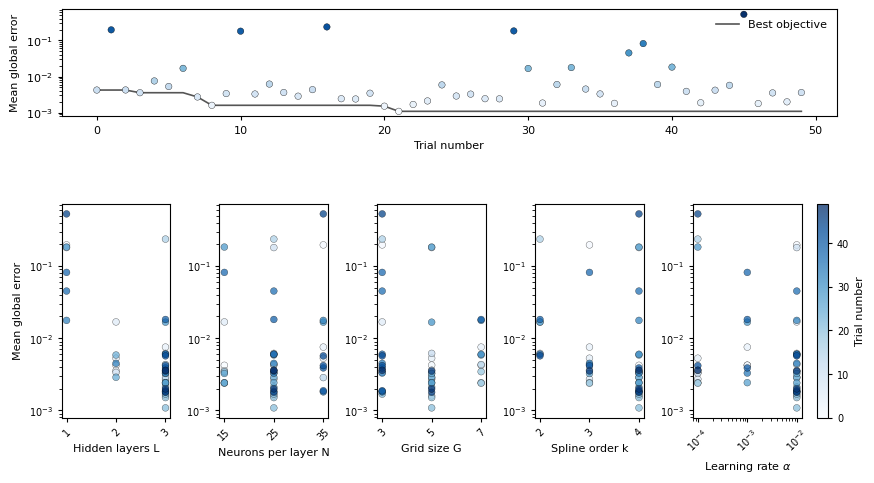

In [10]:
from pathlib import Path
from matplotlib.colors import LogNorm, Normalize
import pandas as pd

# Select the newest Optuna export that is available.
results_root = Path(".")
study_paths = sorted(results_root.glob("results_kan_optuna_2026-09-14_21-57-58/data/study.csv"))
summary_paths = sorted(results_root.glob("results_kan_optuna_2026-09-14_21-57-58/summary_metrics.csv"))

if study_paths:
    source_path = study_paths[-1]
    trials = pd.read_csv(source_path)
    trials = trials[trials["state"].eq("COMPLETE")].copy()
    trials["objective"] = trials["value"]
    parameter_columns = {
        "hidden_layers": "params_hidden_layers",
        "hidden_units": "params_hidden_units",
        "grid_size": "params_grid_size",
        "spline_order": "params_spline_order",
        "learning_rate": "params_learning_rate",
    }
else:
    if not summary_paths:
        raise FileNotFoundError("No study.csv or summary_metrics.csv was found.")
    source_path = summary_paths[-1]
    trials = pd.read_csv(source_path).copy()
    trials = trials.assign(number=np.arange(len(trials)))
    trials["objective"] = trials["mean_global_error"]
    parameter_columns = {
        "hidden_layers": "hidden_layers",
        "hidden_units": "hidden_units",
        "grid_size": "grid_size",
        "spline_order": "spline_order",
        "learning_rate": "adam_lr",
    }

trials = trials.sort_values("number").reset_index(drop=True)
trials = trials[trials["objective"] > 0].copy()
if trials.empty:
    raise ValueError("The selected result file has no positive completed objectives.")

best_index = trials["objective"].idxmin()
best_trial = trials.loc[best_index]
print(f"Source: {source_path}")
print(f"Best objective: {best_trial['objective']:.6e}")
for name, column in parameter_columns.items():
    print(f"{name}: {best_trial[column]}")

# Build a two-panel figure: history and parameter slices.
fig = plt.figure(figsize=(10, 5.3))
grid = fig.add_gridspec(2, 1, height_ratios=(1.0, 2.0), hspace=0.55)

ax_history = fig.add_subplot(grid[0, 0])
best_values = trials["objective"].cummin()
ax_history.plot(
    trials["number"],
    best_values,
    color="#555555",
    linewidth=1.2,
    label="Best objective",
)
ax_history.scatter(
    trials["number"],
    trials["objective"],
    c=trials["objective"],
    cmap="Blues",
    norm=LogNorm(trials["objective"].min(), trials["objective"].max()),
    edgecolors="black",
    linewidths=0.25,
    s=22,
    zorder=2,
)
ax_history.set_yscale("log")
ax_history.set_ylabel("Mean global error")
ax_history.set_xlabel("Trial number")
ax_history.legend(frameon=False, fontsize=8)

parameters = list(parameter_columns)
slice_grid = grid[1, 0].subgridspec(1, len(parameters), wspace=0.45)
axes = [fig.add_subplot(slice_grid[0, index]) for index in range(len(parameters))]
trial_norm = Normalize(trials["number"].min(), trials["number"].max())
for index, (name, column) in enumerate(parameter_columns.items()):
    axis = axes[index]
    values = trials[column]
    scatter = axis.scatter(
        values,
        trials["objective"],
        c=trials["number"],
        cmap="Blues",
        norm=trial_norm,
        edgecolors="black",
        linewidths=0.25,
        alpha=0.75,
        s=24,
    )
    axis.set_yscale("log")
    axis.set_xlabel({
        "hidden_layers": "Hidden layers L",
        "hidden_units": "Neurons per layer N",
        "grid_size": "Grid size G",
        "spline_order": "Spline order k",
        "learning_rate": r"Learning rate $\alpha$",
    }[name], fontsize=8)
    if index == 0:
        axis.set_ylabel("Mean global error")
    axis.tick_params(axis="both", labelsize=7)
    if name == "learning_rate":
        axis.set_xscale("log")
    if values.nunique() <= 10:
        axis.set_xticks(sorted(values.unique()))
        axis.tick_params(axis="x", rotation=45)

colorbar = fig.colorbar(scatter, ax=axes, pad=0.02, fraction=0.025)
colorbar.set_label("Trial number", fontsize=8)
colorbar.ax.tick_params(labelsize=7)

figure_dir = Path("figures")
figure_dir.mkdir(exist_ok=True)
plt.savefig(figure_dir / "kan_hyperparameter_optimization.svg", dpi=300, bbox_inches="tight")
plt.savefig(figure_dir / "kan_hyperparameter_optimization.pdf", dpi=300, bbox_inches="tight")
plt.show()